# Variance Decomposition: Is There Enough Village-Level Signal?

This notebook implements the analytical framework from `approach_variance.md` to answer: **after removing weather-driven variation, is there enough residual village-level signal to reliably identify "relatively worst" villages?**

We fit a sequence of hierarchical mixed-effects models:
- **Model A** — Unconditional (null model, no weather)
- **Model B** — Weather-conditional (random intercepts)  
- **Model C** — Weather × Village interaction (random slopes)
- **Model D** — Village-varying covariates and their weather interaction

Then we examine variance components and produce diagnostic graphs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from math import radians, cos, sin, asin, sqrt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

## Step 1: Data Preparation — Merge Water Quality with Inferred Villages

Replicate the merge from `village_water_qual.ipynb`: infer villages for ponds using coordinate proximity, then merge with WQ data. We keep pond-level observations (not aggregated to village-day) for the mixed-effects models.

In [2]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * 6371 * asin(sqrt(a))

# Load datasets
df_wq = pd.read_csv('data/water_quality.csv')
df_loc = pd.read_csv('data/Shared_ 2026 Github ARA Pond IDs Key.csv')

# Clean location data
df_loc_clean = df_loc[['public_pond_id', 'region', 'village', 'latitude', 'longitude']].copy()
df_loc_clean['latitude'] = pd.to_numeric(df_loc_clean['latitude'], errors='coerce')
df_loc_clean['longitude'] = pd.to_numeric(df_loc_clean['longitude'], errors='coerce')
df_loc_clean['has_coords'] = df_loc_clean['latitude'].notna() & df_loc_clean['longitude'].notna()
df_loc_clean['has_village'] = df_loc_clean['village'].notna() & df_loc_clean['village'].astype(str).str.strip().ne('')

# Reference ponds (with village and coords)
ref_ponds = df_loc_clean[df_loc_clean['has_coords'] & df_loc_clean['has_village']].copy()

def infer_village(row):
    if row['has_village']:
        return row['village']
    if not row['has_coords']:
        return None
    min_dist = float('inf')
    best_village = None
    for _, ref in ref_ponds.iterrows():
        d = haversine_km(row['latitude'], row['longitude'], ref['latitude'], ref['longitude'])
        if d < min_dist:
            min_dist = d
            best_village = ref['village']
    return best_village

df_loc_clean['inferred_village'] = df_loc_clean.apply(infer_village, axis=1)

# Rename WQ columns
df_wq = df_wq.rename(columns={
    'Date of data collection': 'Date',
    'Time of data collection': 'Time',
    'DO (mg/L)': 'DO',
    'Temp (in °C)': 'Water Temperature'
})
df_wq['Date'] = pd.to_datetime(df_wq['Date'])

# Merge WQ with inferred locations
df_merged = df_wq.merge(
    df_loc_clean[['public_pond_id', 'inferred_village', 'region', 'has_coords']],
    left_on='pond_id', right_on='public_pond_id', how='left',
    suffixes=('', '_loc')
)

# Keep ponds with location and Morning observations
df_clean = df_merged[
    df_merged['inferred_village'].notna() & 
    (df_merged['Type'].str.lower() == 'morning')
].copy()

# Use region from location file where available, fall back to WQ region
df_clean['region'] = df_clean['region_loc'].fillna(df_clean['region'])
df_clean = df_clean.drop(columns=['public_pond_id', 'region_loc'], errors='ignore')

print(f"Morning observations with inferred village: {len(df_clean):,}")
print(f"Unique villages: {df_clean['inferred_village'].nunique()}")
print(f"Unique ponds: {df_clean['pond_id'].nunique()}")
print(f"Date range: {df_clean['Date'].min().date()} to {df_clean['Date'].max().date()}")
print(f"\nObservations per region:")
print(df_clean['region'].value_counts())

Morning observations with inferred village: 5,140
Unique villages: 22
Unique ponds: 251
Date range: 2021-07-06 to 2026-01-27

Observations per region:
region
Eluru      3476
Nellore    1664
Name: count, dtype: int64


## Step 3: Merge Weather with WQ and Prepare Village-Varying Covariates

We merge weather features by region and date. For village-varying (time-varying) covariates, we use the fields available in the WQ data itself: **stocking density**, **feed amount**, and **fish weight**. We forward-fill these within each pond to handle the fact that they're recorded intermittently.

In [30]:
# Load weather features from CSV and filter to morning only
_wf_raw = pd.read_csv('data/weather_features.csv')
_wf_raw['Date'] = pd.to_datetime(_wf_raw['datetime']).dt.normalize()
_wf_raw = _wf_raw[_wf_raw['Type'].str.lower() == 'morning']

# Keep only the weather feature columns + merge keys, rename to expected names
_weather_col_map = {
    'shortwave_sum_24h': 'cum_radiation_24h',
    'shortwave_sum_48h': 'cum_radiation_48h',
    'temp_max_24h': 'max_temp_24h',
    'wind_min_overnight': 'min_wind_24h',
    'precip_sum_48h': 'total_precip_48h',
    'vpd_mean_24h': 'mean_vpd_24h',
}
_keep_cols = ['region', 'Date'] + list(_weather_col_map.keys())
weather_features = (
    _wf_raw[_keep_cols]
    .rename(columns=_weather_col_map)
    .groupby(['region', 'Date'])
    .first()
    .reset_index()
)

# Merge weather features with WQ data
df_analysis = df_clean.merge(weather_features, on=['region', 'Date'], how='inner')

print(f"Observations after weather merge: {len(df_analysis):,}")
print(f"Lost {len(df_clean) - len(df_analysis):,} obs (dates outside weather range)")

# Prepare village-varying covariates from WQ data
# Forward-fill stocking density, feed amount, and weight within each pond
df_analysis = df_analysis.sort_values(['pond_id', 'Date'])
for col in ['Stocking density (per acre)', 'Feed amount (kg)', 'Weight']:
    df_analysis[col] = pd.to_numeric(df_analysis[col], errors='coerce')
    df_analysis[col] = df_analysis.groupby('pond_id')[col].ffill()

# Create village-level time-varying covariates: average across ponds in the village on each date
village_covs = df_analysis.groupby(['inferred_village', 'Date']).agg(
    village_stocking_density=('Stocking density (per acre)', 'mean'),
    village_feed_amount=('Feed amount (kg)', 'mean'),
    village_fish_weight=('Weight', 'mean')
).reset_index()

# Merge back to observation level
df_analysis = df_analysis.merge(village_covs, on=['inferred_village', 'Date'], how='left')

# Create binary low-DO indicator (< 3 mg/L)
df_analysis['low_DO'] = (df_analysis['DO'] < 3).astype(int)

# Report completeness
print(f"\nCovariate completeness:")
for col in ['village_stocking_density', 'village_feed_amount', 'village_fish_weight']:
    pct = df_analysis[col].notna().mean() * 100
    print(f"  {col}: {pct:.0f}% non-null")

print(f"\nLow-DO rate: {df_analysis['low_DO'].mean():.3f} ({df_analysis['low_DO'].sum()} events)")
print(f"Villages: {df_analysis['inferred_village'].nunique()}")
print(f"Ponds: {df_analysis['pond_id'].nunique()}")

Observations after weather merge: 5,138
Lost 2 obs (dates outside weather range)

Covariate completeness:
  village_stocking_density: 94% non-null
  village_feed_amount: 98% non-null
  village_fish_weight: 77% non-null

Low-DO rate: 0.114 (586 events)
Villages: 22
Ponds: 251


In [7]:
# Standardise continuous predictors for model stability
weather_vars = ['cum_radiation_24h', 'cum_radiation_48h', 'max_temp_24h',
                'min_wind_24h', 'total_precip_48h', 'mean_vpd_24h']
village_varying_vars = ['village_stocking_density', 'village_fish_weight']

all_pred_vars = weather_vars + village_varying_vars

for col in all_pred_vars:
    mean = df_analysis[col].mean()
    std = df_analysis[col].std()
    if std > 0:
        df_analysis[f'{col}_z'] = (df_analysis[col] - mean) / std
    else:
        df_analysis[f'{col}_z'] = 0.0

# Create standardised variable name lists
weather_vars_z = [f'{v}_z' for v in weather_vars]
village_varying_z = [f'{v}_z' for v in village_varying_vars]

# Encode village as categorical
df_analysis['village_cat'] = pd.Categorical(df_analysis['inferred_village'])
df_analysis['pond_cat'] = pd.Categorical(df_analysis['pond_id'])

# Drop rows with missing DO
df_model = df_analysis.dropna(subset=['DO'] + weather_vars_z).copy()
print(f"Modelling dataset: {len(df_model):,} observations")
print(f"Villages: {df_model['village_cat'].nunique()}, Ponds: {df_model['pond_cat'].nunique()}")

Modelling dataset: 5,130 observations
Villages: 22, Ponds: 251


## Step 4: Fit Hierarchical Models

### Model A — Unconditional (Null Model)

$$\text{DO}_{ijt} = \mu + u_j + v_{ij} + \epsilon_{ijt}$$

where $u_j \sim N(0, \sigma^2_{\text{village}})$, $v_{ij} \sim N(0, \sigma^2_{\text{pond}})$.

This gives us the baseline ICC: what fraction of DO variation is between villages before accounting for weather.

In [8]:
from statsmodels.regression.mixed_linear_model import MixedLM

# Helper to extract variance components from a fitted MixedLM model
def extract_variances(result, model_name):
    """Extract variance components from a statsmodels MixedLM result."""
    resid_var = result.scale  # residual variance
    
    # Random effects variances
    re_cov = result.cov_re
    if hasattr(re_cov, 'values'):
        # For models with named random effects
        re_vars = {}
        if re_cov.shape[0] == 1:
            re_vars['village'] = re_cov.iloc[0, 0]
        else:
            for i, name in enumerate(re_cov.index):
                re_vars[name] = re_cov.iloc[i, i]
    else:
        re_vars = {'village': float(re_cov)}
    
    return {
        'model': model_name,
        'random_effects': re_vars,
        'residual_var': resid_var,
        'log_likelihood': result.llf,
        'aic': 2 * result.df_modelwc - 2 * result.llf,
        'n_obs': result.nobs
    }

# ── Model A: Null model with village random intercept ──
# statsmodels MixedLM doesn't directly support crossed random effects 
# (village + pond), so we nest pond within village using village as the 
# grouping variable first, then add pond as a separate model.

# Model A1: Village-only random intercept
model_a1 = MixedLM.from_formula(
    'DO ~ 1',
    groups='inferred_village',
    data=df_model
)
result_a1 = model_a1.fit(reml=True)
print("=" * 60)
print("MODEL A1: Null model — Village random intercept only")
print("=" * 60)
print(result_a1.summary())

var_a1 = extract_variances(result_a1, 'A1_village_only')
village_var = var_a1['random_effects']['Group Var']  if 'Group Var' in var_a1['random_effects'] else list(var_a1['random_effects'].values())[0]
total_var = village_var + var_a1['residual_var']
icc_village = village_var / total_var
print(f"\nσ²_village = {village_var:.4f}")
print(f"σ²_residual = {var_a1['residual_var']:.4f}")
print(f"ICC_village = {icc_village:.4f} ({icc_village*100:.1f}%)")

MODEL A1: Null model — Village random intercept only
            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   DO        
No. Observations:   5130      Method:               REML      
No. Groups:         22        Scale:                0.6784    
Min. group size:    4         Log-Likelihood:       -6307.9254
Max. group size:    808       Converged:            Yes       
Mean group size:    233.2                                     
--------------------------------------------------------------
                     Coef. Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            3.513    0.041 86.582 0.000  3.433  3.592
inferred_village Var 0.029    0.013                           


σ²_village = 0.0291
σ²_residual = 0.6784
ICC_village = 0.0411 (4.1%)


In [10]:
# Model A2: Pond-within-village random intercept
# Use village as group with random intercept (re_formula='1') + pond as VC
model_a2 = MixedLM.from_formula(
    'DO ~ 1',
    groups='inferred_village',
    re_formula='1',
    vc_formula={'pond': '0 + C(pond_id)'},
    data=df_model
)
result_a2 = model_a2.fit(reml=True)
print("=" * 60)
print("MODEL A2: Null model — Village + Pond random intercepts")
print("=" * 60)
print(result_a2.summary())

# Extract variances
re_cov_a2 = result_a2.cov_re
village_var_a2 = re_cov_a2.iloc[0, 0] if re_cov_a2.size > 0 else 0
pond_var_a2 = result_a2.vcomp[0] if len(result_a2.vcomp) > 0 else 0
resid_var_a2 = result_a2.scale
total_var_a2 = village_var_a2 + pond_var_a2 + resid_var_a2

print(f"\nσ²_village  = {village_var_a2:.4f} ({village_var_a2/total_var_a2*100:.1f}%)")
print(f"σ²_pond     = {pond_var_a2:.4f} ({pond_var_a2/total_var_a2*100:.1f}%)")
print(f"σ²_residual = {resid_var_a2:.4f} ({resid_var_a2/total_var_a2*100:.1f}%)")
print(f"Total       = {total_var_a2:.4f}")
print(f"\nICC_village = {village_var_a2/total_var_a2:.4f}")
print(f"ICC_pond    = {pond_var_a2/total_var_a2:.4f}")

MODEL A2: Null model — Village + Pond random intercepts
            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   DO        
No. Observations:   5130      Method:               REML      
No. Groups:         22        Scale:                0.6466    
Min. group size:    4         Log-Likelihood:       -6261.2075
Max. group size:    808       Converged:            Yes       
Mean group size:    233.2                                     
--------------------------------------------------------------
                     Coef. Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            3.514    0.039 89.816 0.000  3.437  3.591
inferred_village Var 0.022    0.012                           
pond Var             0.035    0.008                           


σ²_village  = 0.0224 (3.2%)
σ²_pond     = 0.0351 (5.0%)
σ²_residual = 0.6466 (91.8%)
Total       = 0.7040

ICC_village = 0.0318
ICC_pond

### Model B — Weather-Conditional (Random Intercepts)

$$\text{DO}_{ijt} = \mu + \mathbf{w}_t'\boldsymbol{\beta} + u_j + v_{ij} + \epsilon_{ijt}$$

Adding weather fixed effects. The key comparison: does $\sigma^2_{\text{village}}$ sharpen once weather is controlled? Does the conditional ICC increase?

In [12]:
# Model B: Weather fixed effects + village random intercept + pond VC
weather_formula = ' + '.join(weather_vars_z)

model_b = MixedLM.from_formula(
    f'DO ~ {weather_formula}',
    groups='inferred_village',
    re_formula='1',
    vc_formula={'pond': '0 + C(pond_id)'},
    data=df_model
)
result_b = model_b.fit(reml=True)
print("=" * 60)
print("MODEL B: Weather fixed effects + Village/Pond random intercepts")
print("=" * 60)
print(result_b.summary())

re_cov_b = result_b.cov_re
village_var_b = re_cov_b.iloc[0, 0] if re_cov_b.size > 0 else 0
pond_var_b = result_b.vcomp[0] if len(result_b.vcomp) > 0 else 0
resid_var_b = result_b.scale
total_var_b = village_var_b + pond_var_b + resid_var_b

# Weather-explained variance (reduction in total random variance from Model A)
weather_explained = total_var_a2 - total_var_b

print(f"\nσ²_village  = {village_var_b:.4f} ({village_var_b/total_var_b*100:.1f}%)")
print(f"σ²_pond     = {pond_var_b:.4f} ({pond_var_b/total_var_b*100:.1f}%)")
print(f"σ²_residual = {resid_var_b:.4f} ({resid_var_b/total_var_b*100:.1f}%)")
print(f"\nConditional ICC_village = {village_var_b/total_var_b:.4f}")
print(f"\nVariance explained by weather: {weather_explained:.4f} " 
      f"({weather_explained/total_var_a2*100:.1f}% of total Model A variance)")
print(f"\nComparison A→B:")
print(f"  Village var: {village_var_a2:.4f} → {village_var_b:.4f} (Δ = {village_var_b - village_var_a2:+.4f})")
print(f"  Pond var:    {pond_var_a2:.4f} → {pond_var_b:.4f}")
print(f"  Residual:    {resid_var_a2:.4f} → {resid_var_b:.4f}")

MODEL B: Weather fixed effects + Village/Pond random intercepts
             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   DO        
No. Observations:    5130      Method:               REML      
No. Groups:          22        Scale:                0.6432    
Min. group size:     4         Log-Likelihood:       -6265.9795
Max. group size:     808       Converged:            Yes       
Mean group size:     233.2                                     
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             3.512    0.039 91.050 0.000  3.437  3.588
cum_radiation_24h_z   0.082    0.025  3.212 0.001  0.032  0.132
cum_radiation_48h_z  -0.049    0.027 -1.823 0.068 -0.102  0.004
max_temp_24h_z       -0.029    0.024 -1.204 0.229 -0.076  0.018
min_wind_24h_z        0.023    0.012  1.898 0.058 -0.

### Model C — Weather × Village Interaction (Random Slopes)

$$\text{DO}_{ijt} = \mu + \mathbf{w}_t'\boldsymbol{\beta} + u_j + \mathbf{w}_t'\mathbf{b}_j + v_{ij} + \epsilon_{ijt}$$

We add village-specific random slopes for the two key weather variables: **cumulative radiation 48h** and **max temperature 24h**. This captures which villages collapse harder under bad weather.

In [13]:
# Model C: Weather fixed effects + village random intercept + random slopes for key weather vars
# Random slopes for cum_radiation_48h and max_temp_24h
model_c = MixedLM.from_formula(
    f'DO ~ {weather_formula}',
    groups='inferred_village',
    re_formula='1 + cum_radiation_48h_z + max_temp_24h_z',
    vc_formula={'pond': '0 + C(pond_id)'},
    data=df_model
)
result_c = model_c.fit(reml=True)
print("=" * 60)
print("MODEL C: Weather + Village random slopes (radiation, temperature)")
print("=" * 60)
print(result_c.summary())

# Extract variance components
re_cov_c = result_c.cov_re
village_var_c = re_cov_c.iloc[0, 0]  # Intercept variance
slope_rad_var_c = re_cov_c.loc['cum_radiation_48h_z', 'cum_radiation_48h_z'] if 'cum_radiation_48h_z' in re_cov_c.index else 0
slope_temp_var_c = re_cov_c.loc['max_temp_24h_z', 'max_temp_24h_z'] if 'max_temp_24h_z' in re_cov_c.index else 0
pond_var_c = result_c.vcomp[0] if len(result_c.vcomp) > 0 else 0
resid_var_c = result_c.scale

print(f"\nRandom effects covariance matrix:")
print(re_cov_c.round(4))
print(f"\nσ²_village (intercept) = {village_var_c:.4f}")
print(f"σ²_slope_radiation     = {slope_rad_var_c:.4f}")
print(f"σ²_slope_temperature   = {slope_temp_var_c:.4f}")
print(f"σ²_pond                = {pond_var_c:.4f}")
print(f"σ²_residual            = {resid_var_c:.4f}")

print(f"\nComparison B→C:")
print(f"  Village var: {village_var_b:.4f} → {village_var_c:.4f}")
print(f"  Residual:    {resid_var_b:.4f} → {resid_var_c:.4f}")
print(f"  New: random slope variances = {slope_rad_var_c:.4f} (radiation), {slope_temp_var_c:.4f} (temp)")

MODEL C: Weather + Village random slopes (radiation, temperature)
                        Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          DO        
No. Observations:            5130             Method:                      REML      
No. Groups:                  22               Scale:                       0.6394    
Min. group size:             4                Log-Likelihood:              -6257.6712
Max. group size:             808              Converged:                   Yes       
Mean group size:             233.2                                                   
-------------------------------------------------------------------------------------
                                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------
Intercept                                   3.512    0.039 90.134 0.000  3.436  3.588
cum_radiatio

### Model D — Village-Varying Covariates and Weather × Village-State Interaction

$$\text{DO}_{ijt} = \mu + \mathbf{w}_t'\boldsymbol{\beta} + u_j + \mathbf{w}_t'\mathbf{b}_j + \mathbf{z}_{jt}'\boldsymbol{\gamma} + (\mathbf{w}_t \otimes \mathbf{z}_{jt})'\boldsymbol{\delta} + v_{ij} + \epsilon_{ijt}$$

Here $\mathbf{z}_{jt}$ are the observed time-varying village covariates (stocking density, fish weight). The interaction terms $(\mathbf{w}_t \otimes \mathbf{z}_{jt})$ capture whether certain management conditions amplify the weather effect (e.g., high stocking density × low radiation → worse DO).

We restrict to observations where village-varying covariates are available.

In [14]:
# Model D: Add village-varying covariates and their interaction with key weather vars
# Restrict to rows with village-varying covariates available
df_model_d = df_model.dropna(subset=['village_stocking_density_z', 'village_fish_weight_z']).copy()
print(f"Model D dataset: {len(df_model_d):,} obs ({len(df_model_d)/len(df_model)*100:.0f}% of full)")
print(f"Villages: {df_model_d['inferred_village'].nunique()}, Ponds: {df_model_d['pond_id'].nunique()}")

# Build formula with village-varying covariates + interactions
village_cov_formula = ' + '.join(village_varying_z)
# Interaction: key weather vars × village-varying covariates
interaction_terms = []
key_weather = ['cum_radiation_48h_z', 'max_temp_24h_z']
for w in key_weather:
    for z in village_varying_z:
        interaction_terms.append(f'{w}:{z}')
interaction_formula = ' + '.join(interaction_terms)

full_formula = f'DO ~ {weather_formula} + {village_cov_formula} + {interaction_formula}'
print(f"\nFormula: {full_formula}")

model_d = MixedLM.from_formula(
    full_formula,
    groups='inferred_village',
    re_formula='1 + cum_radiation_48h_z + max_temp_24h_z',
    vc_formula={'pond': '0 + C(pond_id)'},
    data=df_model_d
)
result_d = model_d.fit(reml=True)
print("\n" + "=" * 60)
print("MODEL D: Weather + Village-varying covariates + Interactions")
print("=" * 60)
print(result_d.summary())

# Extract variance components
re_cov_d = result_d.cov_re
village_var_d = re_cov_d.iloc[0, 0]
slope_rad_var_d = re_cov_d.loc['cum_radiation_48h_z', 'cum_radiation_48h_z'] if 'cum_radiation_48h_z' in re_cov_d.index else 0
slope_temp_var_d = re_cov_d.loc['max_temp_24h_z', 'max_temp_24h_z'] if 'max_temp_24h_z' in re_cov_d.index else 0
pond_var_d = result_d.vcomp[0] if len(result_d.vcomp) > 0 else 0
resid_var_d = result_d.scale

print(f"\nσ²_village (intercept) = {village_var_d:.4f}")
print(f"σ²_slope_radiation     = {slope_rad_var_d:.4f}")
print(f"σ²_slope_temperature   = {slope_temp_var_d:.4f}")
print(f"σ²_pond                = {pond_var_d:.4f}")
print(f"σ²_residual            = {resid_var_d:.4f}")

Model D dataset: 3,934 obs (77% of full)
Villages: 22, Ponds: 244

Formula: DO ~ cum_radiation_24h_z + cum_radiation_48h_z + max_temp_24h_z + min_wind_24h_z + total_precip_48h_z + mean_vpd_24h_z + village_stocking_density_z + village_fish_weight_z + cum_radiation_48h_z:village_stocking_density_z + cum_radiation_48h_z:village_fish_weight_z + max_temp_24h_z:village_stocking_density_z + max_temp_24h_z:village_fish_weight_z

MODEL D: Weather + Village-varying covariates + Interactions
                          Mixed Linear Model Regression Results
Model:                        MixedLM            Dependent Variable:            DO        
No. Observations:             3934               Method:                        REML      
No. Groups:                   22                 Scale:                         0.5323    
Min. group size:              4                  Log-Likelihood:                -4442.5140
Max. group size:              636                Converged:                     Yes   

## Step 5: Variance Partition Comparison

We also need to refit Models A–C on the same subset used for Model D, so that the variance decomposition is comparable across all four models.

In [16]:
# Refit A, B, C on the Model D subset for comparable variance decomposition
print("Refitting Models A, B, C on the Model D subset for comparable decomposition...\n")

# A* on D subset
model_a_d = MixedLM.from_formula('DO ~ 1', groups='inferred_village',
                                  re_formula='1',
                                  vc_formula={'pond': '0 + C(pond_id)'}, data=df_model_d)
result_a_d = model_a_d.fit(reml=True)

# B* on D subset
model_b_d = MixedLM.from_formula(f'DO ~ {weather_formula}', groups='inferred_village',
                                  re_formula='1',
                                  vc_formula={'pond': '0 + C(pond_id)'}, data=df_model_d)
result_b_d = model_b_d.fit(reml=True)

# C* on D subset
model_c_d = MixedLM.from_formula(f'DO ~ {weather_formula}', groups='inferred_village',
                                  re_formula='1 + cum_radiation_48h_z + max_temp_24h_z',
                                  vc_formula={'pond': '0 + C(pond_id)'}, data=df_model_d)
result_c_d = model_c_d.fit(reml=True)

def get_components(result, has_slopes=False):
    """Extract variance components into a dict."""
    re_cov = result.cov_re
    # Handle empty cov_re (no random effects estimated)
    if hasattr(re_cov, 'size') and re_cov.size > 0:
        village_int = re_cov.iloc[0, 0]
    else:
        village_int = 0
    slope_rad = re_cov.loc['cum_radiation_48h_z', 'cum_radiation_48h_z'] if has_slopes and 'cum_radiation_48h_z' in getattr(re_cov, 'index', []) else 0
    slope_temp = re_cov.loc['max_temp_24h_z', 'max_temp_24h_z'] if has_slopes and 'max_temp_24h_z' in getattr(re_cov, 'index', []) else 0
    pond = result.vcomp[0] if len(result.vcomp) > 0 else 0
    resid = result.scale
    return {
        'village_intercept': village_int,
        'slope_radiation': slope_rad,
        'slope_temperature': slope_temp,
        'pond': pond,
        'residual': resid
    }

comps = {
    'Model A\n(null)': get_components(result_a_d),
    'Model B\n(+weather)': get_components(result_b_d),
    'Model C\n(+weather×village)': get_components(result_c_d, has_slopes=True),
    'Model D\n(+village covariates)': get_components(result_d, has_slopes=True)
}

# Build comparison DataFrame
comp_df = pd.DataFrame(comps).T
comp_df['total'] = comp_df.sum(axis=1)

# Compute weather-explained as reduction in total random variance relative to null
comp_df['weather_explained'] = comp_df.loc['Model A\n(null)', 'total'] - comp_df['total']
comp_df.loc['Model A\n(null)', 'weather_explained'] = 0

print("Variance Components (absolute):")
print(comp_df.round(4))

# Proportions
prop_df = comp_df.drop(columns=['total', 'weather_explained']).copy()
for col in prop_df.columns:
    prop_df[col] = comp_df[col] / comp_df.loc['Model A\n(null)', 'total'] * 100

# Add weather explained as proportion of null total
prop_df['weather_fixed_effects'] = comp_df['weather_explained'] / comp_df.loc['Model A\n(null)', 'total'] * 100

print("\nVariance as % of Model A total:")
print(prop_df.round(2))

Refitting Models A, B, C on the Model D subset for comparable decomposition...

Variance Components (absolute):
                                village_intercept  slope_radiation  \
Model A\n(null)                            0.0169           0.0000   
Model B\n(+weather)                        0.0149           0.0000   
Model C\n(+weather×village)                0.0056           0.0184   
Model D\n(+village covariates)             0.0137           0.0023   

                                slope_temperature    pond  residual   total  \
Model A\n(null)                            0.0000  0.0172    0.5404  0.5745   
Model B\n(+weather)                        0.0000  0.0175    0.5350  0.5674   
Model C\n(+weather×village)                0.0107  0.0277    0.5266  0.5890   
Model D\n(+village covariates)             0.0033  0.0166    0.5323  0.5682   

                                weather_explained  
Model A\n(null)                            0.0000  
Model B\n(+weather)                  

### Graph 1 — Variance Partition Bar Chart

The single most important summary graphic. Shows the proportion of DO variance attributed to each source across all four models.

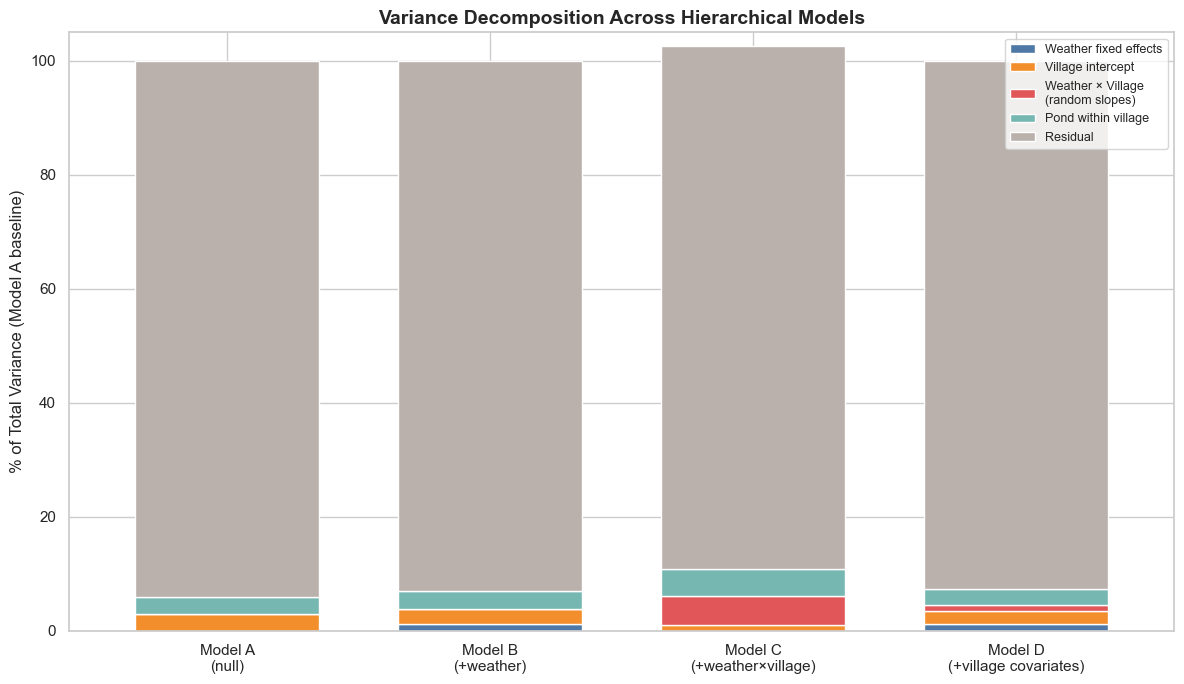


Key findings:
  Village ICC (null):         2.9%
  Village ICC (weather-adj):  2.6%
  Weather explained:          1.2%
  Weather × Village slopes:   5.1%


In [17]:
# Graph 1: Stacked variance partition bar chart
null_total = comp_df.loc['Model A\n(null)', 'total']

plot_data = []
for model_name in comp_df.index:
    row = comp_df.loc[model_name]
    we = row['weather_explained']
    plot_data.append({
        'Model': model_name,
        'Weather fixed effects': we / null_total * 100,
        'Village intercept': row['village_intercept'] / null_total * 100,
        'Weather × Village\n(random slopes)': (row['slope_radiation'] + row['slope_temperature']) / null_total * 100,
        'Pond within village': row['pond'] / null_total * 100,
        'Residual': row['residual'] / null_total * 100,
    })

plot_df = pd.DataFrame(plot_data).set_index('Model')

colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#bab0ac']
ax = plot_df.plot(kind='bar', stacked=True, figsize=(12, 7), color=colors, edgecolor='white', width=0.7)
ax.set_ylabel('% of Total Variance (Model A baseline)')
ax.set_title('Variance Decomposition Across Hierarchical Models', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 105)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Print interpretation
print("\nKey findings:")
village_pct_a = comp_df.loc['Model A\n(null)', 'village_intercept'] / null_total * 100
village_pct_b = comp_df.loc['Model B\n(+weather)', 'village_intercept'] / null_total * 100
weather_pct = comp_df.loc['Model B\n(+weather)', 'weather_explained'] / null_total * 100
slope_pct_c = (comp_df.loc['Model C\n(+weather×village)', 'slope_radiation'] + comp_df.loc['Model C\n(+weather×village)', 'slope_temperature']) / null_total * 100

print(f"  Village ICC (null):         {village_pct_a:.1f}%")
print(f"  Village ICC (weather-adj):  {village_pct_b:.1f}%")
print(f"  Weather explained:          {weather_pct:.1f}%")
print(f"  Weather × Village slopes:   {slope_pct_c:.1f}%")

### Graph 2 — Caterpillar Plot of Village Random Effects (Model B)

Shows $\hat{u}_j \pm 1.96 \cdot SE(\hat{u}_j)$ for each village, ordered by estimate. Confidence intervals that don't overlap indicate reliably distinguishable villages.

Random effect keys: ['inferred_village', 'pond[C(pond_id)[pond_07ed9225]]', 'pond[C(pond_id)[pond_1dbb9f8d]]', 'pond[C(pond_id)[pond_2ec8980d]]', 'pond[C(pond_id)[pond_4cef5872]]', 'pond[C(pond_id)[pond_ba85724b]]'], using 'inferred_village' for intercept


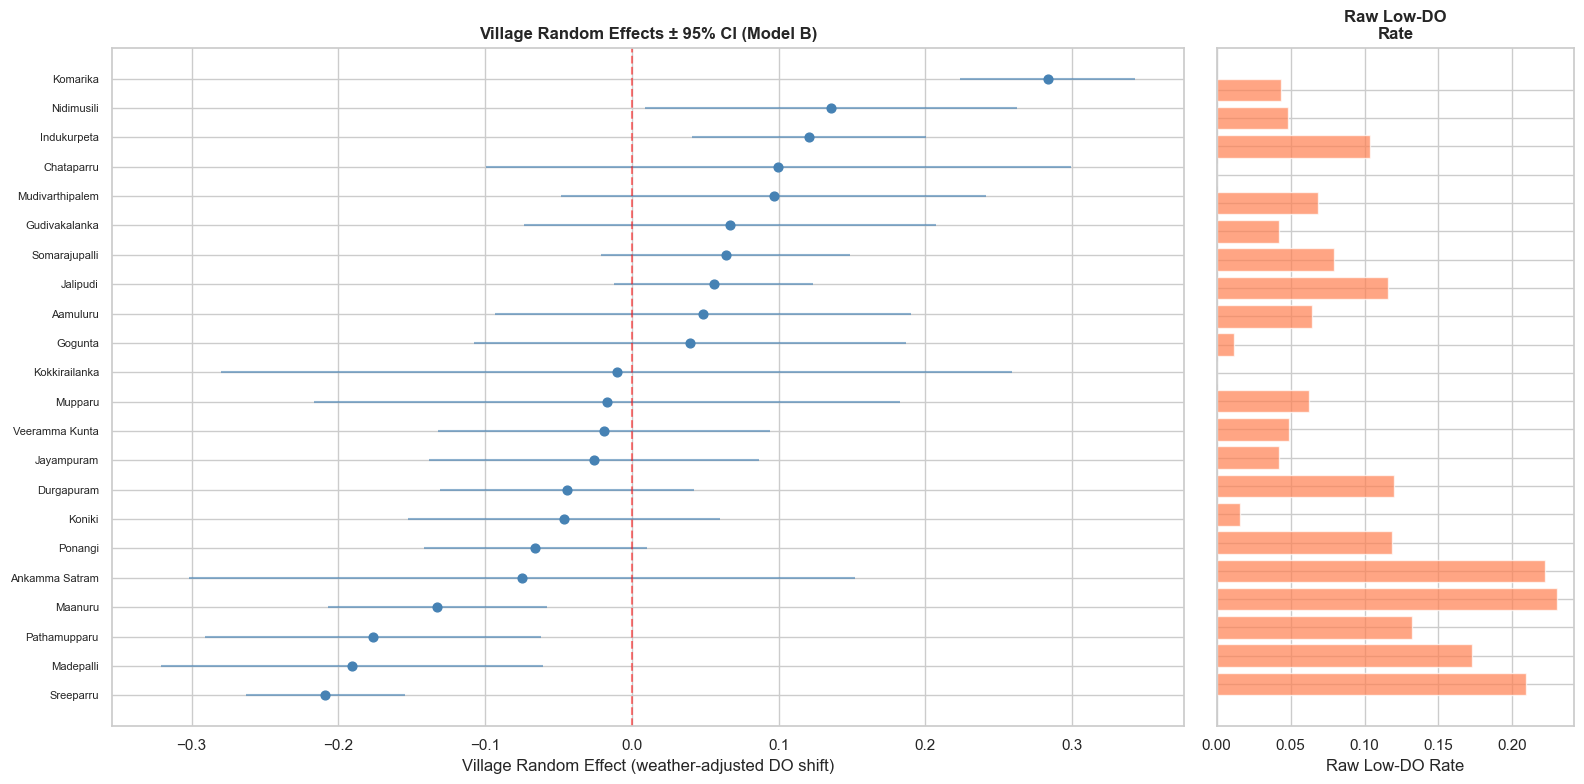


47 of 231 village pairs have non-overlapping 95% CIs (20%)


In [19]:
# Graph 2: Caterpillar plot of village random effects from Model B
re_b = result_b.random_effects

# Determine the key name for the intercept random effect
sample_keys = list(list(re_b.values())[0].keys())
intercept_key = sample_keys[0]  # First key is the intercept
print(f"Random effect keys: {sample_keys}, using '{intercept_key}' for intercept")

village_re = pd.DataFrame({
    'village': list(re_b.keys()),
    'estimate': [v[intercept_key] for v in re_b.values()]
})

# Approximate SEs using village variance and within-village sample sizes
n_per_village = df_model.groupby('inferred_village').size()
for idx, row in village_re.iterrows():
    n = n_per_village.get(row['village'], 1)
    se = np.sqrt(village_var_b * resid_var_b / (n * village_var_b + resid_var_b))
    village_re.loc[idx, 'se'] = se

village_re = village_re.sort_values('estimate').reset_index(drop=True)
village_re['lower'] = village_re['estimate'] - 1.96 * village_re['se']
village_re['upper'] = village_re['estimate'] + 1.96 * village_re['se']

# Also compute raw positive rate for comparison
raw_rates = df_model.groupby('inferred_village')['low_DO'].mean().reset_index()
raw_rates.columns = ['village', 'raw_low_do_rate']
village_re = village_re.merge(raw_rates, on='village', how='left')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={'width_ratios': [3, 1]})

# Caterpillar plot
ax1.hlines(range(len(village_re)), village_re['lower'], village_re['upper'], color='steelblue', alpha=0.6)
ax1.scatter(village_re['estimate'], range(len(village_re)), color='steelblue', s=40, zorder=5)
ax1.axvline(0, color='red', linestyle='--', alpha=0.5)
ax1.set_yticks(range(len(village_re)))
ax1.set_yticklabels(village_re['village'], fontsize=8)
ax1.set_xlabel('Village Random Effect (weather-adjusted DO shift)')
ax1.set_title('Village Random Effects ± 95% CI (Model B)', fontweight='bold')

# Raw low-DO rate comparison
ax2.barh(range(len(village_re)), village_re['raw_low_do_rate'], color='coral', alpha=0.7)
ax2.set_yticks(range(len(village_re)))
ax2.set_yticklabels([])
ax2.set_xlabel('Raw Low-DO Rate')
ax2.set_title('Raw Low-DO\nRate', fontweight='bold')

plt.tight_layout()
plt.show()

# Count villages with non-overlapping CIs
n_separated = 0
for i in range(len(village_re)):
    for j in range(i+1, len(village_re)):
        if village_re.iloc[i]['upper'] < village_re.iloc[j]['lower'] or village_re.iloc[j]['upper'] < village_re.iloc[i]['lower']:
            n_separated += 1
n_pairs = len(village_re) * (len(village_re) - 1) / 2
print(f"\n{n_separated:.0f} of {n_pairs:.0f} village pairs have non-overlapping 95% CIs ({n_separated/n_pairs*100:.0f}%)")

### Graph 3 — Weather Sampling Bias

For each village, compare the mean weather conditions at its sampling times against the overall regional distribution. A strong correlation between sampling weather and raw positive rate would indicate sampling confound.

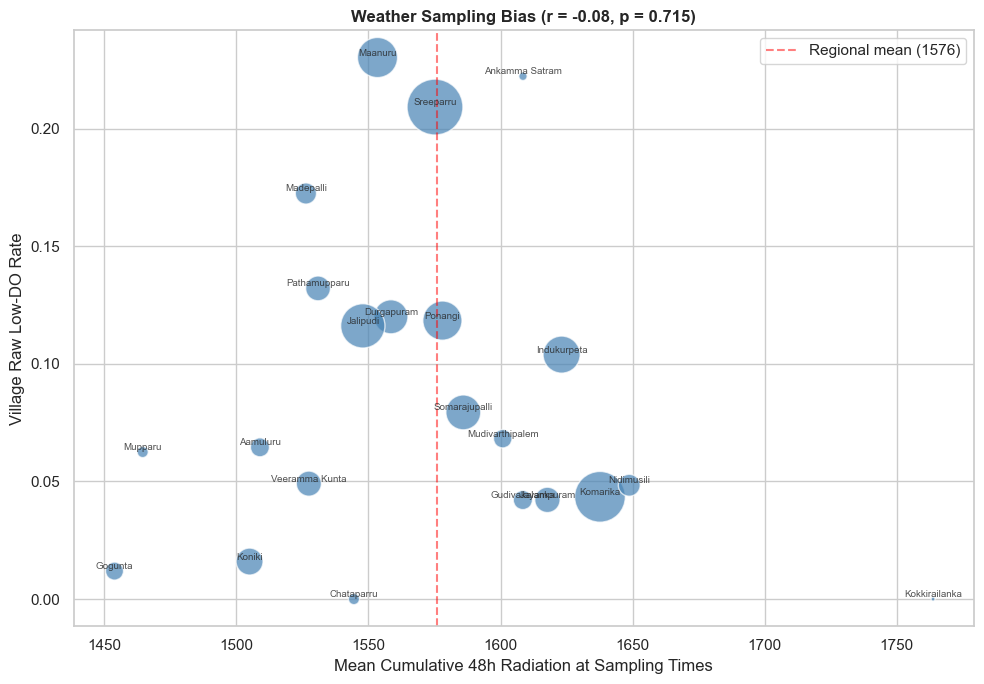

Pearson r = -0.083 (threshold for concern: |r| > 0.3)
✓ Sampling weather bias is modest.


In [20]:
# Graph 3: Weather sampling bias scatter
# Mean sampling-time radiation and positive rate per village
village_weather_bias = df_model.groupby('inferred_village').agg(
    mean_radiation_at_sampling=('cum_radiation_48h', 'mean'),
    mean_temp_at_sampling=('max_temp_24h', 'mean'),
    raw_positive_rate=('low_DO', 'mean'),
    n_obs=('DO', 'count')
).reset_index()

# Regional mean radiation for reference
regional_mean_rad = df_model['cum_radiation_48h'].mean()

from scipy import stats
r_val, p_val = stats.pearsonr(
    village_weather_bias['mean_radiation_at_sampling'].dropna(),
    village_weather_bias['raw_positive_rate'].dropna()
)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    village_weather_bias['mean_radiation_at_sampling'],
    village_weather_bias['raw_positive_rate'],
    s=village_weather_bias['n_obs'] * 2,
    alpha=0.7, c='steelblue', edgecolors='white'
)
for _, row in village_weather_bias.iterrows():
    ax.annotate(row['inferred_village'], (row['mean_radiation_at_sampling'], row['raw_positive_rate']),
                fontsize=7, alpha=0.8, ha='center', va='bottom')

ax.axvline(regional_mean_rad, color='red', linestyle='--', alpha=0.5, label=f'Regional mean ({regional_mean_rad:.0f})')
ax.set_xlabel('Mean Cumulative 48h Radiation at Sampling Times')
ax.set_ylabel('Village Raw Low-DO Rate')
ax.set_title(f'Weather Sampling Bias (r = {r_val:.2f}, p = {p_val:.3f})', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Pearson r = {r_val:.3f} (threshold for concern: |r| > 0.3)")
if abs(r_val) > 0.3:
    print("⚠ Substantial sampling weather bias detected — raw rankings may be confounded.")
else:
    print("✓ Sampling weather bias is modest.")

### Graph 4 — Village-Specific Weather Sensitivity (Model C)

Village-specific random slopes for cumulative radiation — villages with steeper negative slopes are more weather-vulnerable.

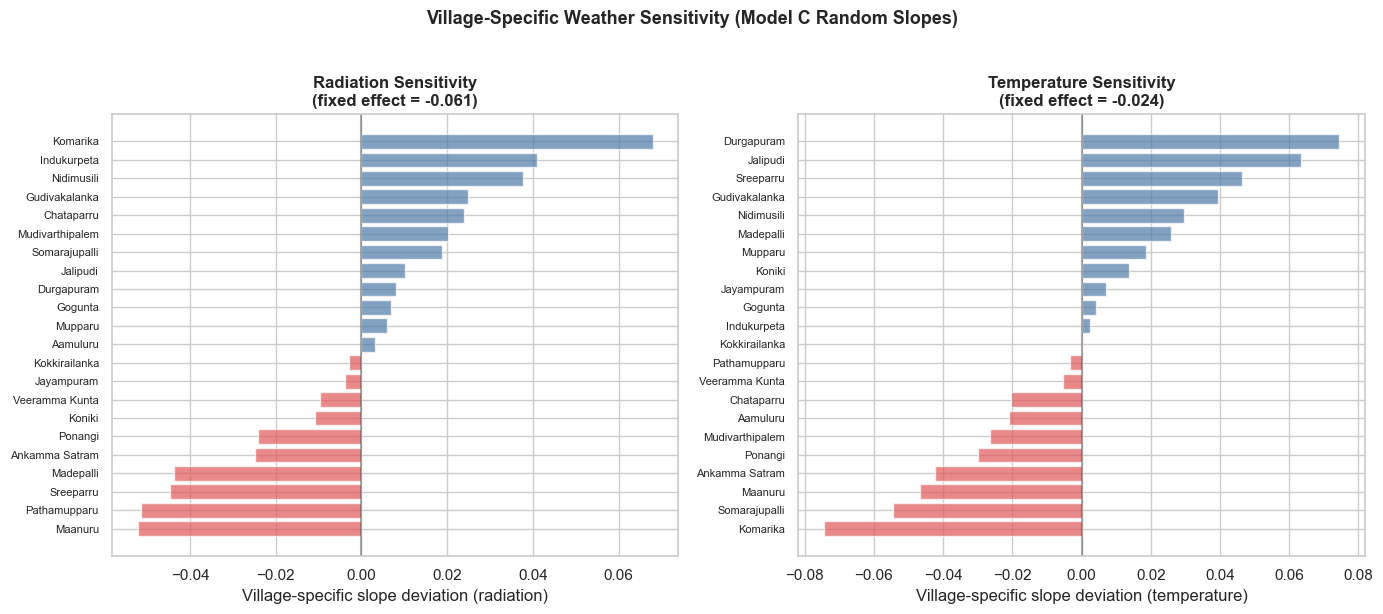

In [21]:
# Graph 4: Village-specific weather sensitivity from Model C random slopes
re_c = result_c.random_effects
slope_data = []
for village, effects in re_c.items():
    slope_data.append({
        'village': village,
        'intercept': effects.get('Group', 0),
        'slope_radiation': effects.get('cum_radiation_48h_z', 0),
        'slope_temperature': effects.get('max_temp_24h_z', 0)
    })
slopes_df = pd.DataFrame(slope_data)

# Fixed effects for reference
fixed_rad = result_c.fe_params.get('cum_radiation_48h_z', 0)
fixed_temp = result_c.fe_params.get('max_temp_24h_z', 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Radiation slopes
slopes_df_sorted = slopes_df.sort_values('slope_radiation')
colors_rad = ['#e15759' if s < 0 else '#4e79a7' for s in slopes_df_sorted['slope_radiation']]
ax1.barh(range(len(slopes_df_sorted)), slopes_df_sorted['slope_radiation'], color=colors_rad, alpha=0.7)
ax1.axvline(0, color='black', linestyle='-', alpha=0.3)
ax1.set_yticks(range(len(slopes_df_sorted)))
ax1.set_yticklabels(slopes_df_sorted['village'], fontsize=8)
ax1.set_xlabel('Village-specific slope deviation (radiation)')
ax1.set_title(f'Radiation Sensitivity\n(fixed effect = {fixed_rad:.3f})', fontweight='bold')

# Temperature slopes
slopes_df_sorted_t = slopes_df.sort_values('slope_temperature')
colors_temp = ['#e15759' if s < 0 else '#4e79a7' for s in slopes_df_sorted_t['slope_temperature']]
ax2.barh(range(len(slopes_df_sorted_t)), slopes_df_sorted_t['slope_temperature'], color=colors_temp, alpha=0.7)
ax2.axvline(0, color='black', linestyle='-', alpha=0.3)
ax2.set_yticks(range(len(slopes_df_sorted_t)))
ax2.set_yticklabels(slopes_df_sorted_t['village'], fontsize=8)
ax2.set_xlabel('Village-specific slope deviation (temperature)')
ax2.set_title(f'Temperature Sensitivity\n(fixed effect = {fixed_temp:.3f})', fontweight='bold')

plt.suptitle('Village-Specific Weather Sensitivity (Model C Random Slopes)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Graph 5 — Sampling Coverage Heatmap

Rows = villages, columns = half-months. Cell colour = number of observations. Second track shows regional weather quality.

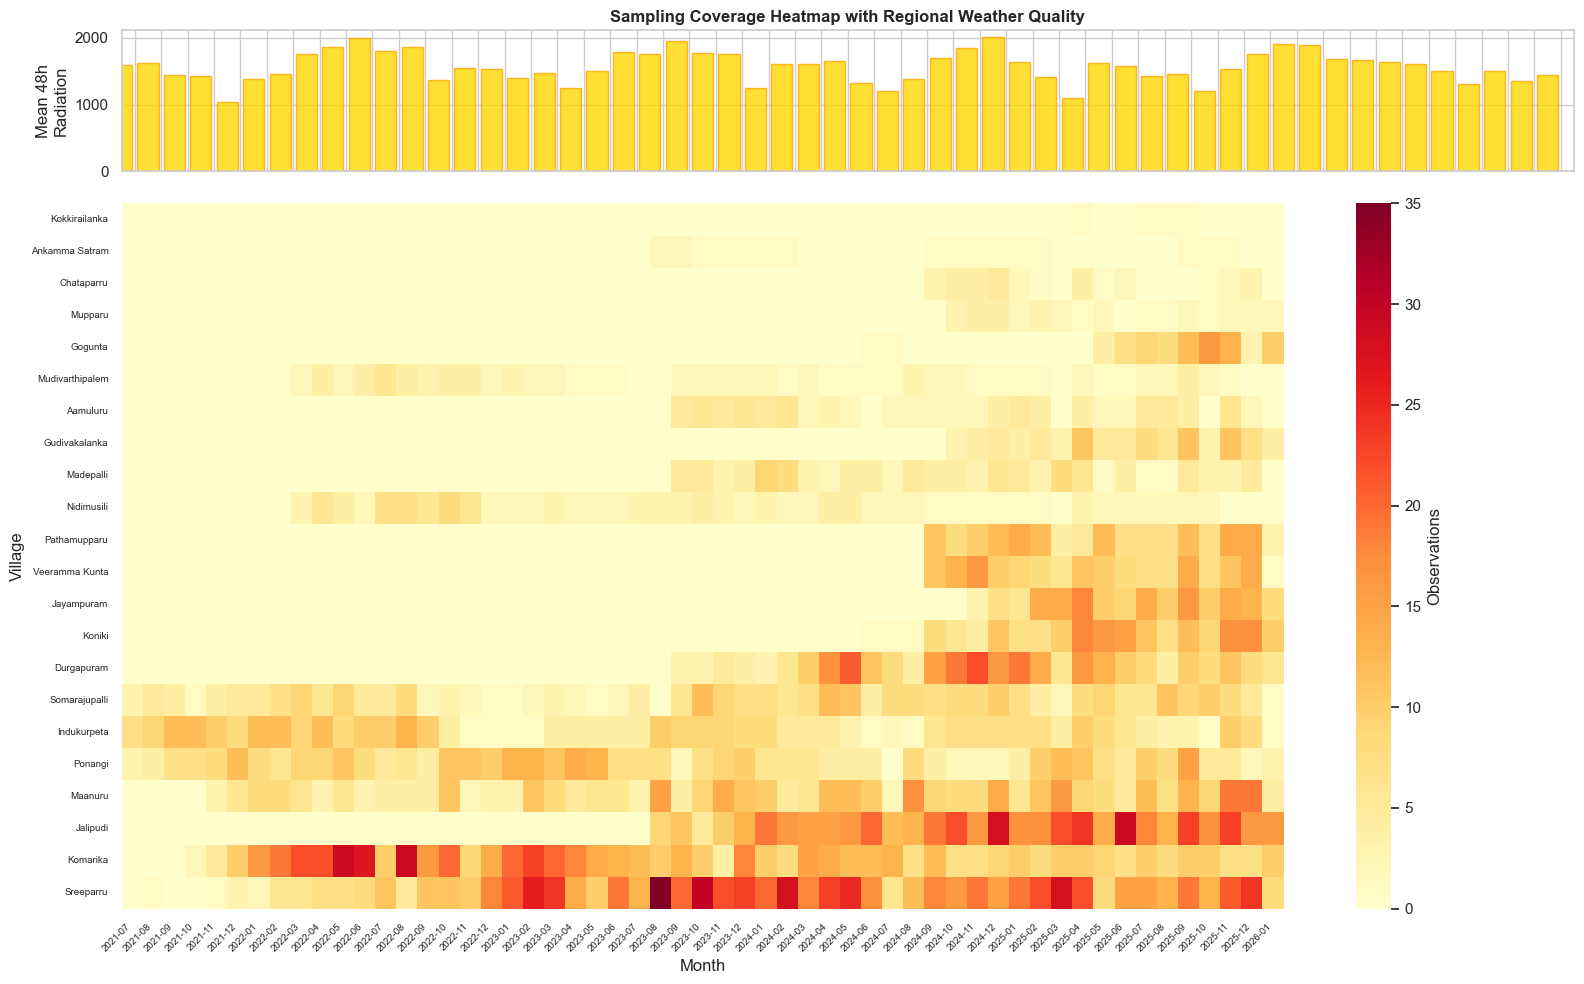

Village-months with 0 observations: 552 of 1210 (46%)
Village-months with ≤2 observations: 698 (58%)


In [22]:
# Graph 5: Sampling coverage heatmap
df_model['year_month'] = df_model['Date'].dt.to_period('M')

# Observation count per village per month
coverage = df_model.groupby(['inferred_village', 'year_month']).size().unstack(fill_value=0)

# Sort villages by total observations
village_order = coverage.sum(axis=1).sort_values(ascending=True).index
coverage = coverage.loc[village_order]

# Mean radiation per month (for weather quality track)
weather_by_month = df_model.groupby('year_month')['cum_radiation_48h'].mean()

fig, (ax_w, ax_h) = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [1, 5]}, sharex=True)

# Weather quality track
months_str = [str(m) for m in coverage.columns]
ax_w.bar(range(len(months_str)), [weather_by_month.get(m, 0) for m in coverage.columns],
         color='gold', alpha=0.8, edgecolor='orange')
ax_w.set_ylabel('Mean 48h\nRadiation')
ax_w.set_title('Sampling Coverage Heatmap with Regional Weather Quality', fontweight='bold')

# Heatmap
sns.heatmap(coverage.values, ax=ax_h, cmap='YlOrRd', cbar_kws={'label': 'Observations'},
            xticklabels=[str(m) for m in coverage.columns], yticklabels=coverage.index)
ax_h.set_xlabel('Month')
ax_h.set_ylabel('Village')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

print(f"Village-months with 0 observations: {(coverage == 0).sum().sum()} "
      f"of {coverage.shape[0] * coverage.shape[1]} ({(coverage == 0).sum().sum() / (coverage.shape[0] * coverage.shape[1]) * 100:.0f}%)")
print(f"Village-months with ≤2 observations: {(coverage <= 2).sum().sum()} "
      f"({(coverage <= 2).sum().sum() / (coverage.shape[0] * coverage.shape[1]) * 100:.0f}%)")

### Graph 6 — Rank Stability (Split-Half)

We compute Spearman rank correlation of village random effects between random split-halves of the data, repeated via bootstrap, to assess how stable village rankings are.

Split-half rank correlations (50 successful bootstraps):
  Mean ρ = 0.819
  Median ρ = 0.818
  95% CI = [0.687, 0.914]


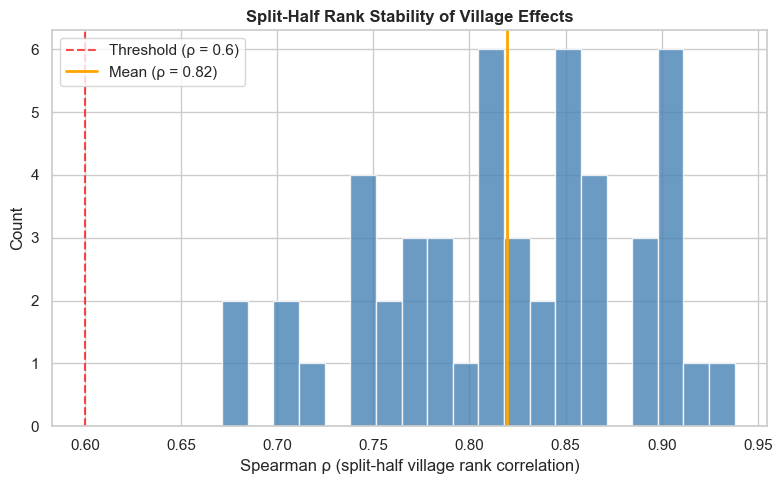

✓ Village rankings are stable across split-halves (ρ > 0.6)


In [24]:
# Graph 6: Split-half rank stability via bootstrap
from scipy.stats import spearmanr

n_bootstrap = 50
rank_corrs = []

for i in range(n_bootstrap):
    # Random split: assign each observation to half A or half B
    idx = np.random.permutation(len(df_model))
    half = len(idx) // 2
    df_a = df_model.iloc[idx[:half]]
    df_b = df_model.iloc[idx[half:]]
    
    try:
        # Fit Model B (village random intercept only, no pond VC for speed) on each half
        res_a = MixedLM.from_formula(
            f'DO ~ {weather_formula}', groups='inferred_village', re_formula='1', data=df_a
        ).fit(reml=True)
        res_b = MixedLM.from_formula(
            f'DO ~ {weather_formula}', groups='inferred_village', re_formula='1', data=df_b
        ).fit(reml=True)
        
        # Get village random effects — intercept key is the groups column name
        intercept_key_a = list(list(res_a.random_effects.values())[0].keys())[0]
        intercept_key_b = list(list(res_b.random_effects.values())[0].keys())[0]
        
        re_a = pd.Series({k: v[intercept_key_a] for k, v in res_a.random_effects.items()})
        re_b = pd.Series({k: v[intercept_key_b] for k, v in res_b.random_effects.items()})
        
        # Align on common villages
        common = re_a.index.intersection(re_b.index)
        if len(common) >= 5:
            rho, _ = spearmanr(re_a[common], re_b[common])
            rank_corrs.append(rho)
    except Exception:
        continue

rank_corrs = np.array(rank_corrs)
print(f"Split-half rank correlations ({len(rank_corrs)} successful bootstraps):")
if len(rank_corrs) > 0:
    print(f"  Mean ρ = {rank_corrs.mean():.3f}")
    print(f"  Median ρ = {np.median(rank_corrs):.3f}")
    print(f"  95% CI = [{np.percentile(rank_corrs, 2.5):.3f}, {np.percentile(rank_corrs, 97.5):.3f}]")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(rank_corrs, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(0.6, color='red', linestyle='--', alpha=0.7, label='Threshold (ρ = 0.6)')
    ax.axvline(rank_corrs.mean(), color='orange', linestyle='-', linewidth=2, label=f'Mean (ρ = {rank_corrs.mean():.2f})')
    ax.set_xlabel('Spearman ρ (split-half village rank correlation)')
    ax.set_ylabel('Count')
    ax.set_title('Split-Half Rank Stability of Village Effects', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

    if rank_corrs.mean() > 0.6:
        print("✓ Village rankings are stable across split-halves (ρ > 0.6)")
    else:
        print("⚠ Village rankings are not stable across split-halves (ρ < 0.6)")
else:
    print("  No successful bootstraps — check model convergence")

## Step 6: Decision Criteria — Is the Data Sufficient?

We assess against the thresholds from the analytical framework:

| Criterion | Threshold for "sufficient" |
|-----------|---------------------------|
| Conditional ICC (village) | > 0.05 |
| Village random effect separation | ≥ 3 villages with non-overlapping CIs |
| Weather sampling bias | \|r\| < 0.3 |
| Effective obs per village | ≥ 50 for top/bottom quartile |

In [26]:
# Decision criteria summary
print("=" * 60)
print("DECISION CRITERIA ASSESSMENT")
print("=" * 60)

# 1. Conditional ICC
cond_icc = village_var_b / total_var_b
icc_pass = cond_icc > 0.05
print(f"\n1. Conditional ICC (village, Model B): {cond_icc:.4f}")
print(f"   Threshold: > 0.05 → {'PASS ✓' if icc_pass else 'FAIL ✗'}")

# 2. Village separation
village_re_sorted = village_re.sort_values('estimate')
separated_villages = set()
for i in range(len(village_re_sorted)):
    for j in range(i+1, len(village_re_sorted)):
        if village_re_sorted.iloc[i]['upper'] < village_re_sorted.iloc[j]['lower']:
            separated_villages.add(village_re_sorted.iloc[i]['village'])
            separated_villages.add(village_re_sorted.iloc[j]['village'])
n_sep = len(separated_villages)
sep_pass = n_sep >= 3
print(f"\n2. Villages with non-overlapping CIs: {n_sep}")
print(f"   Threshold: ≥ 3 → {'PASS ✓' if sep_pass else 'FAIL ✗'}")

# 3. Split-half rank correlation
mean_rho = rank_corrs.mean() if len(rank_corrs) > 0 else 0
rho_pass = mean_rho > 0.6
print(f"\n3. Split-half rank correlation (mean ρ): {mean_rho:.3f}")
print(f"   Threshold: > 0.6 → {'PASS ✓' if rho_pass else 'FAIL ✗'}")

# 4. Weather sampling bias
bias_pass = abs(r_val) < 0.3
print(f"\n4. Weather sampling bias |r|: {abs(r_val):.3f}")
print(f"   Threshold: < 0.3 → {'PASS ✓' if bias_pass else 'FAIL ✗'}")

# 5. Effective obs per village
obs_per_village = df_model.groupby('inferred_village').size()
quartile_cutoff = obs_per_village.quantile(0.75)
q1_villages = obs_per_village[obs_per_village >= quartile_cutoff]
min_top_q = q1_villages.min()
obs_pass = min_top_q >= 50
print(f"\n5. Min obs in top-quartile villages: {min_top_q}")
print(f"   Threshold: ≥ 50 → {'PASS ✓' if obs_pass else 'FAIL ✗'}")

# Overall
n_pass = sum([icc_pass, sep_pass, rho_pass, bias_pass, obs_pass])
print(f"\n{'=' * 60}")
print(f"OVERALL: {n_pass}/5 criteria met")
if n_pass >= 4:
    print("→ Village-level prediction appears FEASIBLE. Proceed to ML with village identity as a feature.")
elif n_pass >= 2:
    print("→ Village-level signal exists but is WEAK. Proceed with caution; consider pooled regional models.")
else:
    print("→ Village-level prediction is NOT FEASIBLE with current sampling density.")

DECISION CRITERIA ASSESSMENT

1. Conditional ICC (village, Model B): 0.0305
   Threshold: > 0.05 → FAIL ✗

2. Villages with non-overlapping CIs: 21
   Threshold: ≥ 3 → PASS ✓

3. Split-half rank correlation (mean ρ): 0.819
   Threshold: > 0.6 → PASS ✓

4. Weather sampling bias |r|: 0.083
   Threshold: < 0.3 → PASS ✓

5. Min obs in top-quartile villages: 356
   Threshold: ≥ 50 → PASS ✓

OVERALL: 4/5 criteria met
→ Village-level prediction appears FEASIBLE. Proceed to ML with village identity as a feature.


## Summary: Scope of Explainability

The table below summarises **how much variation is explained** by each source, answering the core questions:
- Weather alone vs. fixed village effects alone
- Weather × time-varying village variables (management interactions)
- Weather × fixed village identity (unobserved village characteristics)
- Time-varying village variables alone (management main effects)

In [27]:
# Final scope-of-explainability summary
# All computed from the Model D subset for fair comparison
null_total_d = comp_df.loc['Model A\n(null)', 'total']

# Weather alone: variance explained by adding weather fixed effects (A→B)
weather_alone = comp_df.loc['Model B\n(+weather)', 'weather_explained']

# Fixed village identity: village intercept variance in Model B
fixed_village_alone = comp_df.loc['Model B\n(+weather)', 'village_intercept']

# Weather × fixed village (random slopes): additional variance captured C vs B
weather_x_fixed_village = (
    (comp_df.loc['Model C\n(+weather×village)', 'slope_radiation'] + 
     comp_df.loc['Model C\n(+weather×village)', 'slope_temperature'])
)

# Time-varying village covariates alone: reduction in residual+village from adding z_jt (C→D)
# We compare total random variance C to D 
total_c = comp_df.loc['Model C\n(+weather×village)', 'total']
total_d = comp_df.loc['Model D\n(+village covariates)', 'total']
village_covariates_effect = total_c - total_d

# Weather × time-varying village: the interaction terms absorb some slope variance
slope_reduction = (
    (comp_df.loc['Model C\n(+weather×village)', 'slope_radiation'] - 
     comp_df.loc['Model D\n(+village covariates)', 'slope_radiation']) +
    (comp_df.loc['Model C\n(+weather×village)', 'slope_temperature'] - 
     comp_df.loc['Model D\n(+village covariates)', 'slope_temperature'])
)

summary = pd.DataFrame({
    'Source': [
        'Weather alone (fixed effects)',
        'Fixed village identity (intercept)',
        'Weather × fixed village (random slopes)',
        'Time-varying village covariates (main effect)',
        'Weather × village covariates (interaction)',
        'Pond within village',
        'Unexplained (residual)'
    ],
    'Variance': [
        weather_alone,
        comp_df.loc['Model D\n(+village covariates)', 'village_intercept'],
        comp_df.loc['Model D\n(+village covariates)', 'slope_radiation'] + comp_df.loc['Model D\n(+village covariates)', 'slope_temperature'],
        max(0, village_covariates_effect - slope_reduction),
        max(0, slope_reduction),
        comp_df.loc['Model D\n(+village covariates)', 'pond'],
        comp_df.loc['Model D\n(+village covariates)', 'residual']
    ]
})
summary['% of Total'] = (summary['Variance'] / null_total_d * 100).round(1)
summary['Variance'] = summary['Variance'].round(4)

print("SCOPE OF EXPLAINABILITY")
print("=" * 70)
print(summary.to_string(index=False))
print(f"\nTotal null model variance: {null_total_d:.4f}")
print(f"Total explained by all fixed + random effects:")
total_explained = null_total_d - comp_df.loc['Model D\n(+village covariates)', 'residual'] - comp_df.loc['Model D\n(+village covariates)', 'pond']
print(f"  {total_explained:.4f} ({total_explained/null_total_d*100:.1f}%)")

SCOPE OF EXPLAINABILITY
                                       Source  Variance  % of Total
                Weather alone (fixed effects)    0.0070         1.2
           Fixed village identity (intercept)    0.0137         2.4
      Weather × fixed village (random slopes)    0.0056         1.0
Time-varying village covariates (main effect)    0.0000         0.0
   Weather × village covariates (interaction)    0.0236         4.1
                          Pond within village    0.0166         2.9
                       Unexplained (residual)    0.5323        92.7

Total null model variance: 0.5745
Total explained by all fixed + random effects:
  0.0256 (4.4%)
